In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [2]:
df_h = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")   
df_c = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\coma_sample.csv")
df_a = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_shell\gaia_parallax5_10_fidelity.csv") 
df_h = df_h[df_h["phot_g_mean_mag"]<18].copy() 
df_c = df_c[df_c["phot_g_mean_mag"]<18].copy() 
df_a = df_a[df_a["phot_g_mean_mag"]<18].copy()  

In [3]:
def restrict_reference_like_cluster(
    cluster_df,
    gaia_df,
    cols=("parallax", "phot_g_mean_mag", "pmra", "pmdec"),
    q_low=0.05,
    q_high=0.95,
    pad_frac=0.25,
):
    mask = np.ones(len(gaia_df), dtype=bool)

    for col in cols:
        if col not in cluster_df.columns or col not in gaia_df.columns:
            continue

        lo = cluster_df[col].quantile(q_low)
        hi = cluster_df[col].quantile(q_high)

        width = hi - lo
        lo -= pad_frac * width
        hi += pad_frac * width

        mask &= gaia_df[col].between(lo, hi)

    return gaia_df.loc[mask].copy()

In [4]:
def conditional_bootstrap_1d_test(
    cluster_df,
    gaia_df,
    col,
    features=("phot_g_mean_mag", "bp_rp", "parallax"),
    k_neighbors=100,
    n_boot=500,
    seed=42,
    statistic="ks",
):
    """
    Test 1D condicionado por propiedades observacionales.

    En vez de comparar el cúmulo contra todo Gaia, compara contra
    una referencia Gaia localmente parecida en magnitud, color y paralaje.
    """

    rng = np.random.default_rng(seed)

    log_col = f"log10_{col}"

    needed_cols = list(features) + [log_col]

    cluster = cluster_df[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    gaia = gaia_df[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    x_obs = cluster[log_col].to_numpy()
    n = len(x_obs)

    if n == 0:
        raise ValueError("No hay datos válidos en cluster_df.")

    if len(gaia) < k_neighbors:
        raise ValueError("La muestra Gaia es menor que k_neighbors.")

    X_cluster = cluster[list(features)].to_numpy()
    X_gaia = gaia[list(features)].to_numpy()

    scaler = StandardScaler()
    X_gaia_s = scaler.fit_transform(X_gaia)
    X_cluster_s = scaler.transform(X_cluster)

    nn = NearestNeighbors(n_neighbors=k_neighbors)
    nn.fit(X_gaia_s)

    _, indices = nn.kneighbors(X_cluster_s)

    gaia_errors = gaia[log_col].to_numpy()

    # Pool emparejado: todos los vecinos Gaia encontrados para las estrellas del cúmulo
    matched_pool = gaia_errors[indices.ravel()]

    if statistic == "ks":
        t_obs = ks_2samp(x_obs, matched_pool).statistic

        def stat_fun(x):
            return ks_2samp(x, matched_pool).statistic

    elif statistic == "wasserstein":
        t_obs = wasserstein_distance(x_obs, matched_pool)

        def stat_fun(x):
            return wasserstein_distance(x, matched_pool)

    else:
        raise ValueError("statistic debe ser 'ks' o 'wasserstein'.")

    t_boot = np.empty(n_boot)

    for i in range(n_boot):
        # Para cada estrella del cúmulo, escoger uno de sus vecinos Gaia
        chosen_local = rng.integers(0, k_neighbors, size=n)
        chosen_indices = indices[np.arange(n), chosen_local]

        x_boot = gaia_errors[chosen_indices]

        t_boot[i] = stat_fun(x_boot)

    p_value = (np.sum(t_boot >= t_obs) + 1) / (n_boot + 1)

    result = {
        "variable": col,
        "n_cluster": n,
        "n_gaia_reference": len(gaia),
        "k_neighbors": k_neighbors,
        "features": list(features),
        "statistic": statistic,
        "T_obs": t_obs,
        "p_value": p_value,
        "T_boot_median": np.median(t_boot),
        "T_boot_95": np.quantile(t_boot, 0.95),
        "T_boot_99": np.quantile(t_boot, 0.99),
    }

    return result, t_boot

In [13]:
def get_log_errors_with_features(
    df,
    error_cols=("parallax_error", "pmra_error", "pmdec_error"),
    feature_cols=("phot_g_mean_mag", "bp_rp", "parallax"),
):
    """
    Conserva las columnas de errores y también las variables usadas
    para emparejar la muestra Gaia con el cúmulo.

    Crea:
        log10_parallax_error
        log10_pmra_error
        log10_pmdec_error
    """

    # Usar solo columnas que realmente existan en el DataFrame
    available_error_cols = [c for c in error_cols if c in df.columns]
    available_feature_cols = [c for c in feature_cols if c in df.columns]

    missing_errors = [c for c in error_cols if c not in df.columns]
    missing_features = [c for c in feature_cols if c not in df.columns]

    if len(missing_errors) > 0:
        raise ValueError(f"Faltan columnas de error: {missing_errors}")

    if len(missing_features) > 0:
        print(f"Advertencia: faltan columnas de features: {missing_features}")

    cols = available_error_cols + available_feature_cols

    out = df[cols].copy()

    # Convertir a numérico
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    # Filtrar errores válidos
    mask = np.ones(len(out), dtype=bool)

    for col in available_error_cols:
        mask &= np.isfinite(out[col].to_numpy())
        mask &= out[col].to_numpy() > 0

    # Filtrar features válidas también
    for col in available_feature_cols:
        mask &= np.isfinite(out[col].to_numpy())

    out = out.loc[mask].copy()

    # Crear columnas log10(error)
    for col in available_error_cols:
        out[f"log10_{col}"] = np.log10(out[col])

    return out

In [14]:
h_err = get_log_errors_with_features(df_h)
c_err = get_log_errors_with_features(df_c)
a_err = get_log_errors_with_features(df_a)

print("Hyades:", len(h_err))
print("Coma:", len(c_err))
print("Gaia referencia:", len(a_err))

Hyades: 429
Coma: 238
Gaia referencia: 261873


In [18]:
features = ("phot_g_mean_mag", "bp_rp", "parallax")

rows = []

for cluster_name, cluster_df in [("Hyades", h_err), (
    
    
    "Coma", c_err)]:
    for col in ["parallax_error", "pmra_error", "pmdec_error"]:
        for stat in ["ks", "wasserstein"]:
            res, boot = conditional_bootstrap_1d_test(
                cluster_df=cluster_df,
                gaia_df=a_err,
                col=col,
                features=features,
                k_neighbors=100,
                n_boot=50,
                statistic=stat,
                seed=42,
            )
            res["cluster"] = cluster_name
            rows.append(res)

conditional_results = pd.DataFrame(rows)
conditional_results

,variable,n_cluster,n_gaia_reference,k_neighbors,features,statistic,T_obs,p_value,T_boot_median,T_boot_95,T_boot_99,cluster
0,parallax_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.135874,0.019608,0.031620,0.050479,0.053137,Hyades
1,parallax_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.103599,0.019608,0.017240,0.026271,0.034062,Hyades
2,pmra_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.222564,0.019608,0.036970,0.055738,0.059828,Hyades
3,pmra_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.176652,0.019608,0.018891,0.033423,0.039109,Hyades
4,pmdec_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.058065,0.039216,0.031807,0.051719,0.056242,Hyades
5,pmdec_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.059403,0.019608,0.016293,0.027167,0.030960,Hyades
6,parallax_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.129076,0.019608,0.043004,0.063912,0.067360,Coma
7,parallax_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.096520,0.019608,0.021781,0.033649,0.036342,Coma
8,pmra_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.162017,0.019608,0.045504,0.061460,0.068284,Coma
9,pmra_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.111761,0.019608,0.022162,0.036443,0.039246,Coma


In [20]:
alpha = 0.05

conditional_results["compatible_con_gaia"] = conditional_results["p_value"] > alpha

conditional_results

,variable,n_cluster,n_gaia_reference,k_neighbors,features,statistic,T_obs,p_value,T_boot_median,T_boot_95,T_boot_99,cluster,compatible_con_gaia
0,parallax_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.135874,0.019608,0.031620,0.050479,0.053137,Hyades,False
1,parallax_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.103599,0.019608,0.017240,0.026271,0.034062,Hyades,False
2,pmra_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.222564,0.019608,0.036970,0.055738,0.059828,Hyades,False
3,pmra_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.176652,0.019608,0.018891,0.033423,0.039109,Hyades,False
4,pmdec_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.058065,0.039216,0.031807,0.051719,0.056242,Hyades,False
5,pmdec_error,429,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.059403,0.019608,0.016293,0.027167,0.030960,Hyades,False
6,parallax_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.129076,0.019608,0.043004,0.063912,0.067360,Coma,False
7,parallax_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.096520,0.019608,0.021781,0.033649,0.036342,Coma,False
8,pmra_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",ks,0.162017,0.019608,0.045504,0.061460,0.068284,Coma,False
9,pmra_error,238,261873,100,"[phot_g_mean_mag, bp_rp, parallax]",wasserstein,0.111761,0.019608,0.022162,0.036443,0.039246,Coma,False


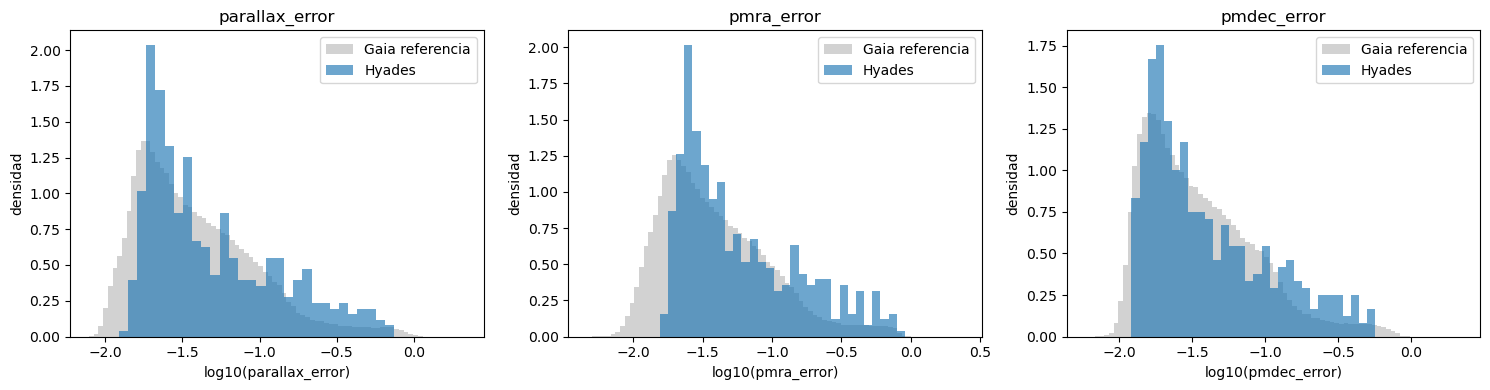

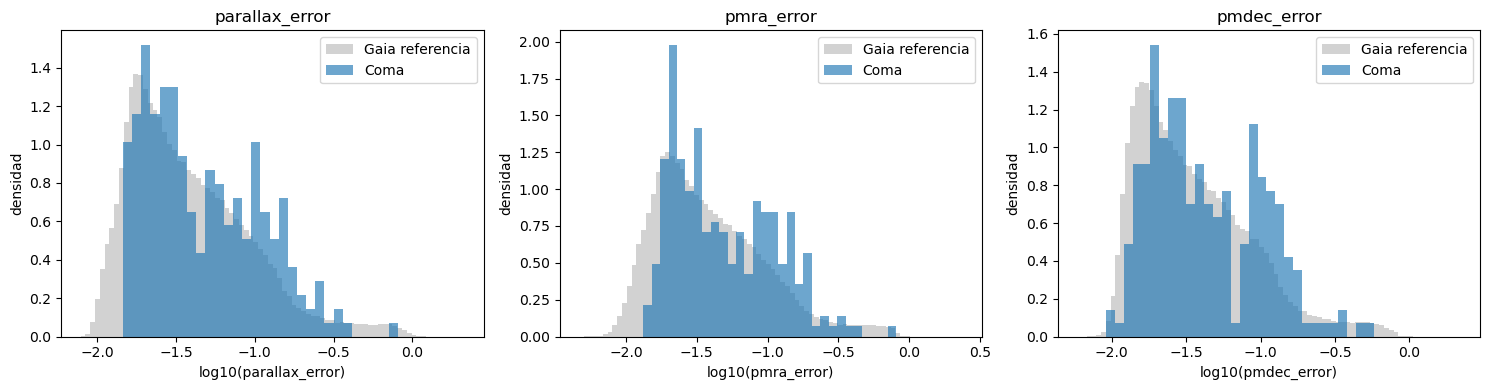

In [22]:

error_cols = ["parallax_error", "pmra_error", "pmdec_error"]
def plot_error_distributions(cluster_df, gaia_df, cluster_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, error_cols):
        x_gaia = gaia_df[f"log10_{col}"].dropna().values
        x_cl = cluster_df[f"log10_{col}"].dropna().values

        ax.hist(
            x_gaia,
            bins=80,
            density=True,
            alpha=0.35,
            label="Gaia referencia",
            color="gray",
        )

        ax.hist(
            x_cl,
            bins=30,
            density=True,
            alpha=0.65,
            label=cluster_name,
        )

        ax.set_xlabel(f"log10({col})")
        ax.set_ylabel("densidad")
        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_error_distributions(h_err, a_err, "Hyades")
plot_error_distributions(c_err, a_err, "Coma")